In [ ]:
import pandas as pd

# Load datasets
df1 = pd.read_csv("/content/StudentPerformance Factors new2.csv")
df2 = pd.read_csv("/content/extra curricular activities.csv")

# Remove duplicates
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)

# Handle missing values
df1.fillna(df1.mean(numeric_only=True), inplace=True)
df2.fillna(df2.mean(numeric_only=True), inplace=True)

for col in df1.select_dtypes(include='object'):
    df1[col].fillna(df1[col].mode()[0], inplace=True)

for col in df2.select_dtypes(include='object'):
    df2[col].fillna(df2[col].mode()[0], inplace=True)

# Clean column names
df1.columns = df1.columns.str.strip().str.lower().str.replace(" ", "_")
df2.columns = df2.columns.str.strip().str.lower().str.replace(" ", "_")

# Save cleaned files
df1.to_csv("clean_student_performance6.csv", index=False)
df2.to_csv("clean_extra_curricular6.csv", index=False)

/tmp/ipykernel_2012/4192759569.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].fillna(df1[col].mode()[0], inplace=True)


In [ ]:
import pandas as pd
file_path = "/content/StudentPerformance Factors new2.csv"
data = pd.read_csv(file_path)
print(data.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions  ... Teacher_Quality School_Type  \
0            

In [ ]:
import pandas as pd
file_path = "/content/extra curricular activities.csv"
data = pd.read_csv(file_path)
print(data.head())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd

# Load datasets
df1 = pd.read_csv("/content/clean_student_performance6.csv")
df2 = pd.read_csv("/content/clean_extra_curricular6.csv")

# Normalize column names
df1.columns = df1.columns.str.strip().str.lower().str.replace(" ", "_")
df2.columns = df2.columns.str.strip().str.lower().str.replace(" ", "_")

# Find common columns
common_cols = list(set(df1.columns) & set(df2.columns))
print("Common column(s):", common_cols)

if common_cols:
    # Prefer unique identifiers if available
    merge_key = None
    for key in ["student_id", "roll_number", "name"]:
        if key in common_cols:
            merge_key = key
            break

    # Fall back to first common column if no unique ID found
    if merge_key is None:
        merge_key = common_cols[0]
        print(f" Warning: merging on '{merge_key}', which may not be unique")

    # Align datatypes for merge key
    df1[merge_key] = df1[merge_key].astype(str)
    df2[merge_key] = df2[merge_key].astype(str)

    # Merge datasets
    integrated_df = pd.merge(
        df1, df2, on=merge_key, how="inner", suffixes=("_perf", "_extra")
    )

    # Save output
    integrated_df.to_csv("integrated_dataset6.csv", index=False)
    print(" Integration completed successfully")
    print("Integrated dataset shape:", integrated_df.shape)
else:
    print(" No common columns found. Integration skipped.")


Common column(s): ['studentid', 'gender']
 Integration completed successfully
Integrated dataset shape: (2392, 35)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the integrated dataset
df = pd.read_csv("/content/integrated_dataset6.csv")

# Handle missing values
# Numerical columns -> fill with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns -> fill with most frequent value
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# Transform categorical attributes into numerical
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Save transformed dataset
df.to_csv("transformed_dataset.csv", index=False)

print("Dataset transformed and saved successfully.")

Dataset transformed and saved successfully.


In [ ]:
import pandas as pd

# Load transformed dataset
df = pd.read_csv("/content/transformed_dataset.csv")

# Define target column
target_column = "gpa"   # change if your target is different

# Calculate correlation with target
correlation = df.corr()[target_column].abs()

# Set correlation threshold
threshold = 0.1

# Select important columns
selected_columns = correlation[correlation >= threshold].index.tolist()

# Create reduced dataset
reduced_df = df[selected_columns]

# Save reduced dataset
reduced_df.to_csv("reduced_dataset.csv", index=False)

print("Dataset reduced successfully.")
print("Selected columns:", selected_columns)

Dataset reduced successfully.
Selected columns: ['studytimeweekly', 'absences', 'tutoring', 'parentalsupport', 'gpa', 'gradeclass']


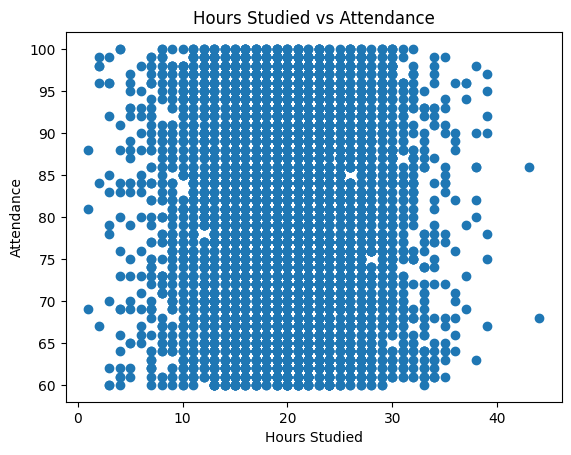

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('clean_student_performance6.csv')

# Scatter plot
plt.figure()
plt.scatter(df['hours_studied'], df['attendance'])

plt.xlabel('Hours Studied')
plt.ylabel('Attendance')
plt.title('Hours Studied vs Attendance')

plt.show()

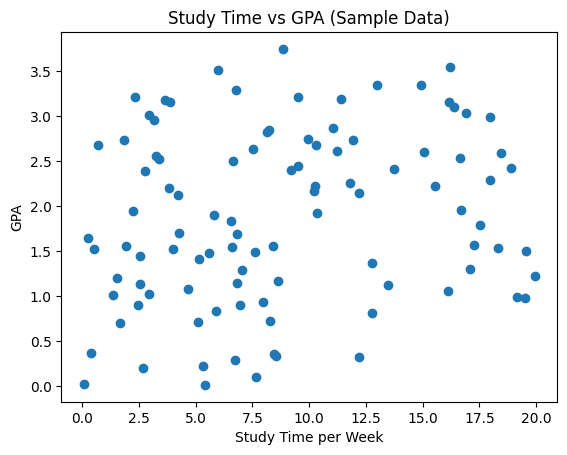

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("extra curricular activities.csv")

# Take only 100 random points (to avoid crowding)
sample_df = df.sample(n=100)

# Scatter plot
plt.scatter(sample_df["StudyTimeWeekly"], sample_df["GPA"])

plt.xlabel("Study Time per Week")
plt.ylabel("GPA")
plt.title("Study Time vs GPA (Sample Data)")

plt.show()

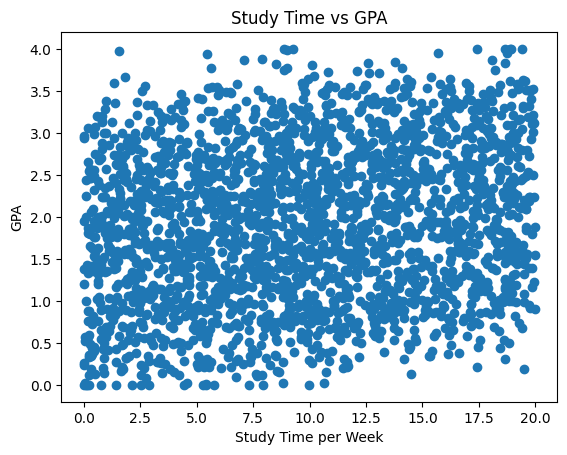

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("clean_extra_curricular6.csv")

# Create a scatter plot: Study Time vs GPA
plt.figure()
plt.scatter(df["studytimeweekly"], df["gpa"])
plt.xlabel("Study Time per Week")
plt.ylabel("GPA")
plt.title("Study Time vs GPA")
plt.show()

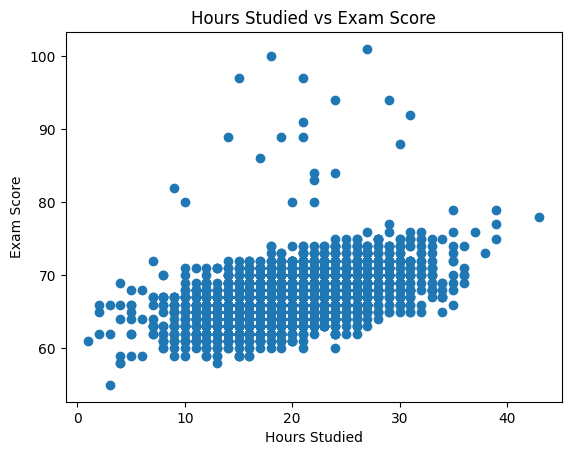

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/transformed_dataset.csv")

# Scatter plot: Hours Studied vs Exam Score
plt.figure()
plt.scatter(df["hours_studied"], df["exam_score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

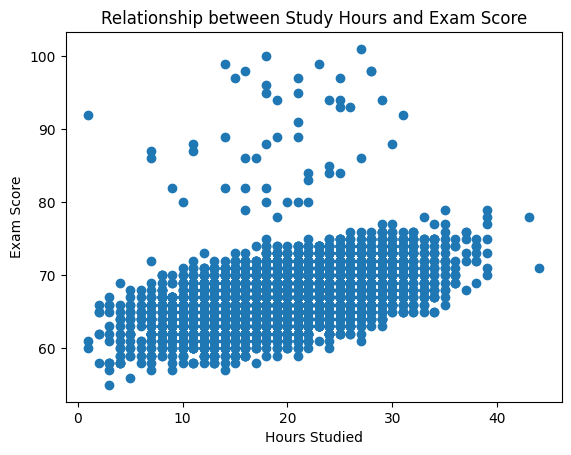

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentPerformance Factors new2.csv")

plt.figure()
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Relationship between Study Hours and Exam Score")
plt.show()

KeyError: 'math_score'

<Figure size 800x600 with 0 Axes>

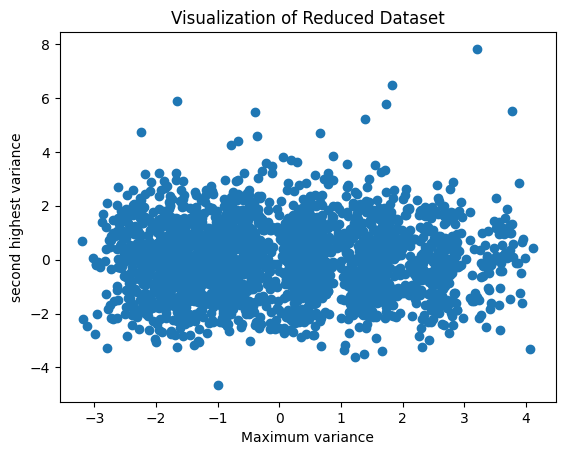

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("reduced_dataset6.csv")

# Take first two columns automatically
x = df.iloc[:, 0]
y = df.iloc[:, 1]

# Plot
plt.figure()
plt.scatter(x, y)
plt.xlabel("Maximum variance")
plt.ylabel("second highest variance")
plt.title("Visualization of Reduced Dataset")
plt.show()